# Notebook 03 — Break it yourself

We implement two attacks on toy LWE and watch how they scale. The lesson: **noise is what makes LWE hard**, and **brute force blows up exponentially** in the dimension.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
from pqc_edu.lwe import toy_keygen
from pqc_edu.attacks import brute_force_secret, gaussian_elimination_noiseless, verify_secret

## Experiment 1 — noise-less LWE is just linear algebra

If $\sigma = 0$, the samples satisfy $b = A s \bmod q$ **exactly**. That is a consistent linear system over $\mathbb{Z}_q$, which Gaussian elimination solves directly in $O(n^3)$ time. Without noise, there is no LWE — it's just linear algebra.

In [2]:
rng = np.random.default_rng(0)
pk, sk = toy_keygen(n=20, q=257, sigma=0.0, rng=rng, m=40)
res = gaussian_elimination_noiseless(pk)
print(f'method: {res.method}, seconds: {res.seconds:.4f}')
print('recovered =', res.secret)
print('expected  =', sk.s)
print('match:', verify_secret(sk, res.secret))

method: gaussian_elimination_noiseless, seconds: 0.0008
recovered = [218 163 131  69  79  10  19   4  45 209 166 234 129 155 249 187 162 139
 143 240]
expected  = [218 163 131  69  79  10  19   4  45 209 166 234 129 155 249 187 162 139
 143 240]
match: True


## Experiment 2 — add noise and linear algebra breaks

Even tiny Gaussian noise $e_i$ means $A s \ne b$ exactly. Gaussian elimination then solves the **wrong** system and returns a garbage secret. Noise is what turns a trivial linear-algebra problem into a hard lattice problem.

In [3]:
rng = np.random.default_rng(0)
pk, sk = toy_keygen(n=20, q=257, sigma=1.5, rng=rng, m=40)
res = gaussian_elimination_noiseless(pk)
print('match:', verify_secret(sk, res.secret))
print('noise breaks linear solve — we get a nonsense secret')

match: False
noise breaks linear solve — we get a nonsense secret


## Experiment 3 — brute force

For tiny $n$ we can simply enumerate all $q^n$ candidate secrets and check each one against the samples. This *always* works in principle, but the work grows **exponentially** in $n$. Let's measure the growth.

n=2: 0.001s, recovered=True
n=3: 0.012s, recovered=True


n=4: 0.212s, recovered=True


n=5: 3.309s, recovered=True


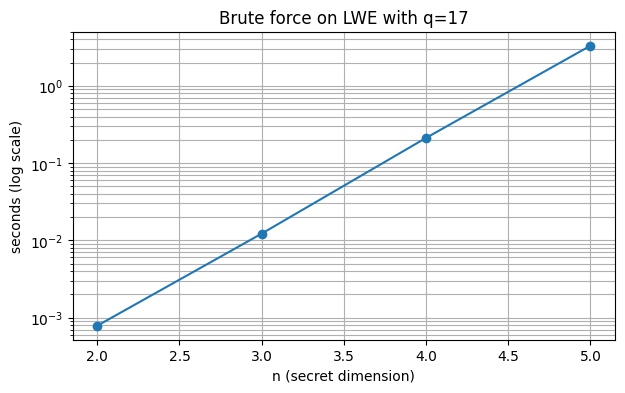

In [4]:
ns = [2, 3, 4, 5]
q = 17  # small q to keep the search space tiny
times = []
for n in ns:
    rng = np.random.default_rng(n)
    pk, sk = toy_keygen(n=n, q=q, sigma=0.5, rng=rng, m=4 * n)
    res = brute_force_secret(pk, error_tolerance=1, time_budget_s=30)
    ok = verify_secret(sk, res.secret)
    print(f'n={n}: {res.seconds:.3f}s, recovered={ok}')
    times.append(res.seconds)

plt.figure(figsize=(7, 4))
plt.semilogy(ns, times, 'o-')
plt.xlabel('n (secret dimension)')
plt.ylabel('seconds (log scale)')
plt.title(f'Brute force on LWE with q={q}')
plt.grid(True, which='both')
plt.show()

## Extrapolation

Each $+1$ to $n$ multiplies the search space by $q$. If $n=5$ took $T$ seconds, then $n=16$ would take $T \cdot q^{11} = T \cdot 17^{11}$ seconds. At $q=17$ that's roughly **35 billion** times slower.

For ML-KEM's real parameters (effective $n=256$, modulus $q=3329$), the numbers are astronomical — well beyond the age of the universe on any classical or quantum hardware.

In [5]:
T_last = times[-1]
n_last = ns[-1]
n_target = 16
factor = q ** (n_target - n_last)
years = T_last * factor / (365.25 * 24 * 3600)
print(f'n={n_target} extrapolated: {years:.2e} years')

n=16 extrapolated: 3.59e+06 years


## State-of-the-art attacks

Real cryptanalysis is **exponentially faster than brute force** — but still exponential in dimension for well-chosen parameters. Key techniques:

- **BKZ lattice reduction** — find short vectors in a lattice built from the samples.
- **Primal / dual embeddings** — reformulate LWE as a uSVP or BDD problem.
- **Dual attacks with hints** — modern variants that exploit structure.

For **ML-KEM-512**, the best known attack costs roughly $2^{143}$ operations. The standard tool for assessing concrete hardness is the **LWE estimator** (Albrecht et al.), which tracks all known attacks and picks the best one for a given parameter set.

→ Next: `04_polynomial_rings.ipynb` — the trick that makes ML-KEM fast.